Notebooken ekstraherer pixel intensiteter fra hyperspektrale billeder:

Måleposition: $X = 623$ og $Y = 595$.  
  

Exposure time: $48.29 \ \text{ms}$

In [2]:
import numpy as np

positions = np.array([-5,-4,-3,-2,-1,0,1,2,3,4,5,6,7,8,9])
wavelengths = np.array([
    979.938423974748,
    965.6355972152284,
    950.178745754072,
    932.3128830871851,
    916.9340081397692,
    900.3670051043612,
    882.8615702963975,
    864.9758373138259,
    847.7957858479577,
    830.512784041971,
    813.6081357352764,
    796.8734931743778,
    780.2526166573507,
    763.9708179240575,
    749.9255375188601
])

a, b = np.polyfit(positions, wavelengths, 1)

print(f"Lambda = {a:.4f} * x + {b:.4f}")

Lambda = -16.7722 * x + 898.6206


$$
\lambda = -16.7722 \cdot x + 898.6206
$$
Isolerer $x$:

$$
x = \frac{\lambda - 898.6206}{-16.7722}
$$

In [3]:
def stage_from_wavelength(lam):
    return (lam - b) / a

for lam in [800, 810, 820, 930, 940, 950]:
    print(f"{lam} nm -> {stage_from_wavelength(lam):.3f} mm")

800 nm -> 5.880 mm
810 nm -> 5.284 mm
820 nm -> 4.688 mm
930 nm -> -1.871 mm
940 nm -> -2.467 mm
950 nm -> -3.063 mm


-------

Transmissionskonstanter for kamera, linser, globar ved alle relevante bølgelængder:

$$
I_{\text{Hyperspekt. output}}​(\lambda) = I_{\text{glo-bar}}​(\lambda) \cdot T_{\text{finger}}(\lambda) \cdot T_{\text{linser}}(\lambda) \cdot T_{\text{filter}}(\lambda) \cdot T_{\text{kamera}}(\lambda)
$$

Isoleret for fingerens relative transmission:

$$
I_{\text{hyperspekt. output}}(\lambda)=
\frac{
\operatorname{median}_{(x,y)\in ROI}\left(I_{\text{finger}}(x,y,\lambda)\right)-
\operatorname{median}\left(I_{\text{dark}}(x,y,\lambda)\right)
}{t_{\text{exp}}}
$$

$$
Finger_{\text{korr}}(\lambda)=
\frac{I_{\text{hyperspekt. output}}(\lambda)}{E_{\text{glo-bar}}(\lambda) \cdot
T_{\text{linse1}}(\lambda) \cdot
T_{\text{linse2}}(\lambda) \cdot
T_{\text{linse3}}(\lambda) \cdot
T_{\text{filter}}(\lambda) \cdot
QE_{\text{kamera}}(\lambda)}
$$

Da den absolutte geometri ikke er kendt, normaliseres signalet til 940 nm:

$$
T_{\text{finger,rel}}(\lambda)=
\frac{Finger_{\text{Korr}}(\lambda)}{Finger_{\text{korr}}(940\,\text{nm})}
$$


For alle de 6 relevante bølgelængder:

||800nm|810nm|820nm|930nm|940nm|950nm|
|-|-|-|-|-|-|-|
|Stage pos.|5.880 mm|5.284 mm|4.688 mm|-1.871 mm|-2.467 mm|-3.063 mm|
|Hyperspekt. output $[\text{counts}/\text{s}]$|$1052.6$|$1157.9$|$1263.2$|$2000.0$|$1789.5$|$1263.2$|
|glo-bar  $\left [\frac{\text{Watt}}{m^2} \right ]$|$1.6630$|$1.8314$|$2.0042$|$4.8737$|$5.2153$|$5.5886$|
|linse 1 (AC254-030-AB)|$0.9893$|$0.9893$|$0.9893$|$0.9892$|$0.9892$|$0.9892$|
|linse 2 (AC127-025-AB)|$0.9885$|$0.9873$|$0.9865$|$0.9730$|$0.9715$|$0.9700$|
|linse 3 (AC127-050-AB)|$0.9885$|$0.9875$|$0.9866$|$0.9728$|$0.9715$|$0.9700$|
|filter|$0.83$|$0.84$|$0.85$|$0.93$|$0.925$|$0.92$|
|kamera (quantum efficiency)|$0.48$|$0.47$|$0.45$|$0.24$|$0.22$|$0.18$|


## Mørkekorrigeret pixelintensitet

For hver bølgelængde læses det beskårne fingerbillede og det tilhørende mørkebillede fra hele sensoren. Den ønskede korrektion er:

$$I_{\text{korrigeret}}(x,y,\lambda) = I_{\text{finger}}(x,y,\lambda) - I_{\text{mørke}}(x,y,\lambda)$$

Fordi fingerbillederne er beskåret, skal mørkepixlen hentes fra samme oprindelige kamerasensor-position. I NumPy/Python-billedarrays er indeksrækkefølgen `[y, x]`, så målepositionen `X = 623`, `Y = 595` læses som `image[595, 623]`. Hvis beskæringen har fjernet pixels over eller til venstre for fingerbilledet, sættes `crop_y_offset` og/eller `crop_x_offset`, før mørkebilledet læses.


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile as tiff

x1, x2 = 280, 800
y1, y2 = 200, 600

t_exp = 9.50e-3  
wavelengths = [800, 810, 820, 930, 940, 950]

data_dir = Path("/home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/raw/daniel")

glo_bar = {
    800: 1.6630,
    810: 1.8314,
    820: 2.0042,
    930: 4.8737,
    940: 5.2153,
    950: 5.5886,
}

lens1 = {
    800: 0.9893,
    810: 0.9893,
    820: 0.9893,
    930: 0.9892,
    940: 0.9892,
    950: 0.9892,
}

lens2 = {
    800: 0.9885,
    810: 0.9873,
    820: 0.9865,
    930: 0.9730,
    940: 0.9715,
    950: 0.9700,
}

lens3 = {
    800: 0.9885,
    810: 0.9875,
    820: 0.9866,
    930: 0.9728,
    940: 0.9715,
    950: 0.9700,
}

filter_T = {
    800: 0.83,
    810: 0.84,
    820: 0.85,
    930: 0.93,
    940: 0.925,
    950: 0.92,
}

camera_QE = {
    800: 0.48,
    810: 0.47,
    820: 0.45,
    930: 0.24,
    940: 0.22,
    950: 0.18,
}

def read_intensity_image(path):
    img = tiff.imread(path).astype(np.float64)

    # TIFFs load as RGBA; RGB contains the rendered grayscale intensity.
    # Ignore alpha, otherwise the constant 255 alpha channel corrupts the median.
    if img.ndim == 3:
        img = img[..., :3].mean(axis=2)

    return img

rows = []

for lam in wavelengths:
    finger = read_intensity_image(data_dir / f"finger{lam}nm.tif")
    dark = read_intensity_image(data_dir / f"dark{lam}nm.tif")

    finger_roi = finger[y1:y2, x1:x2]
    finger_roi_median = np.median(finger_roi)
    dark_median = np.median(dark)

    dark_corrected = finger_roi_median - dark_median
    hyperspekt_output = dark_corrected / t_exp

    instrument_factor_G = (
        glo_bar[lam]
        * lens1[lam]
        * lens2[lam]
        * lens3[lam]
        * filter_T[lam]
        * camera_QE[lam]
    )

    S_corr = hyperspekt_output / instrument_factor_G

    rows.append({
        "Bølgelængde_nm": lam,
        "finger_roi_median": finger_roi_median,
        "Mørkemåling_median": dark_median,
        "Mørkekorrigeret_counts": dark_corrected,
        "hyperspekt_output_counts_per_s": hyperspekt_output,
        "Korrigeret_sample": S_corr,
    })

df = pd.DataFrame(rows)
S_corr_940 = df.loc[df["Bølgelængde_nm"] == 940, "Korrigeret_sample"].iloc[0]
df["relativ_finger_transmission_to_940"] = df["Korrigeret_sample"] / S_corr_940
df["relativ_absorbance_to_940"] = -np.log10(df["relativ_finger_transmission_to_940"])
    
df


,Bølgelængde_nm,finger_roi_median,Mørkemåling_median,Mørkekorrigeret_counts,hyperspekt_output_counts_per_s,Korrigeret_sample,relativ_finger_transmission_to_940,relativ_absorbance_to_940
0,800,21.0,14.0,7.0,736.842105,1150.486427,0.721983,0.141473
1,810,22.0,14.0,8.0,842.105263,1207.512896,0.757770,0.120462
2,820,23.0,14.0,9.0,947.368421,1283.453673,0.805427,0.093974
3,930,19.0,3.0,16.0,1684.210526,1653.571142,1.037692,-0.016069
4,940,17.0,2.0,15.0,1578.947368,1593.507923,1.000000,-0.000000
5,950,13.0,2.0,11.0,1157.894737,1344.244118,0.843575,0.073876


---
## Relativ transmissionsstyrke gennem fingeren


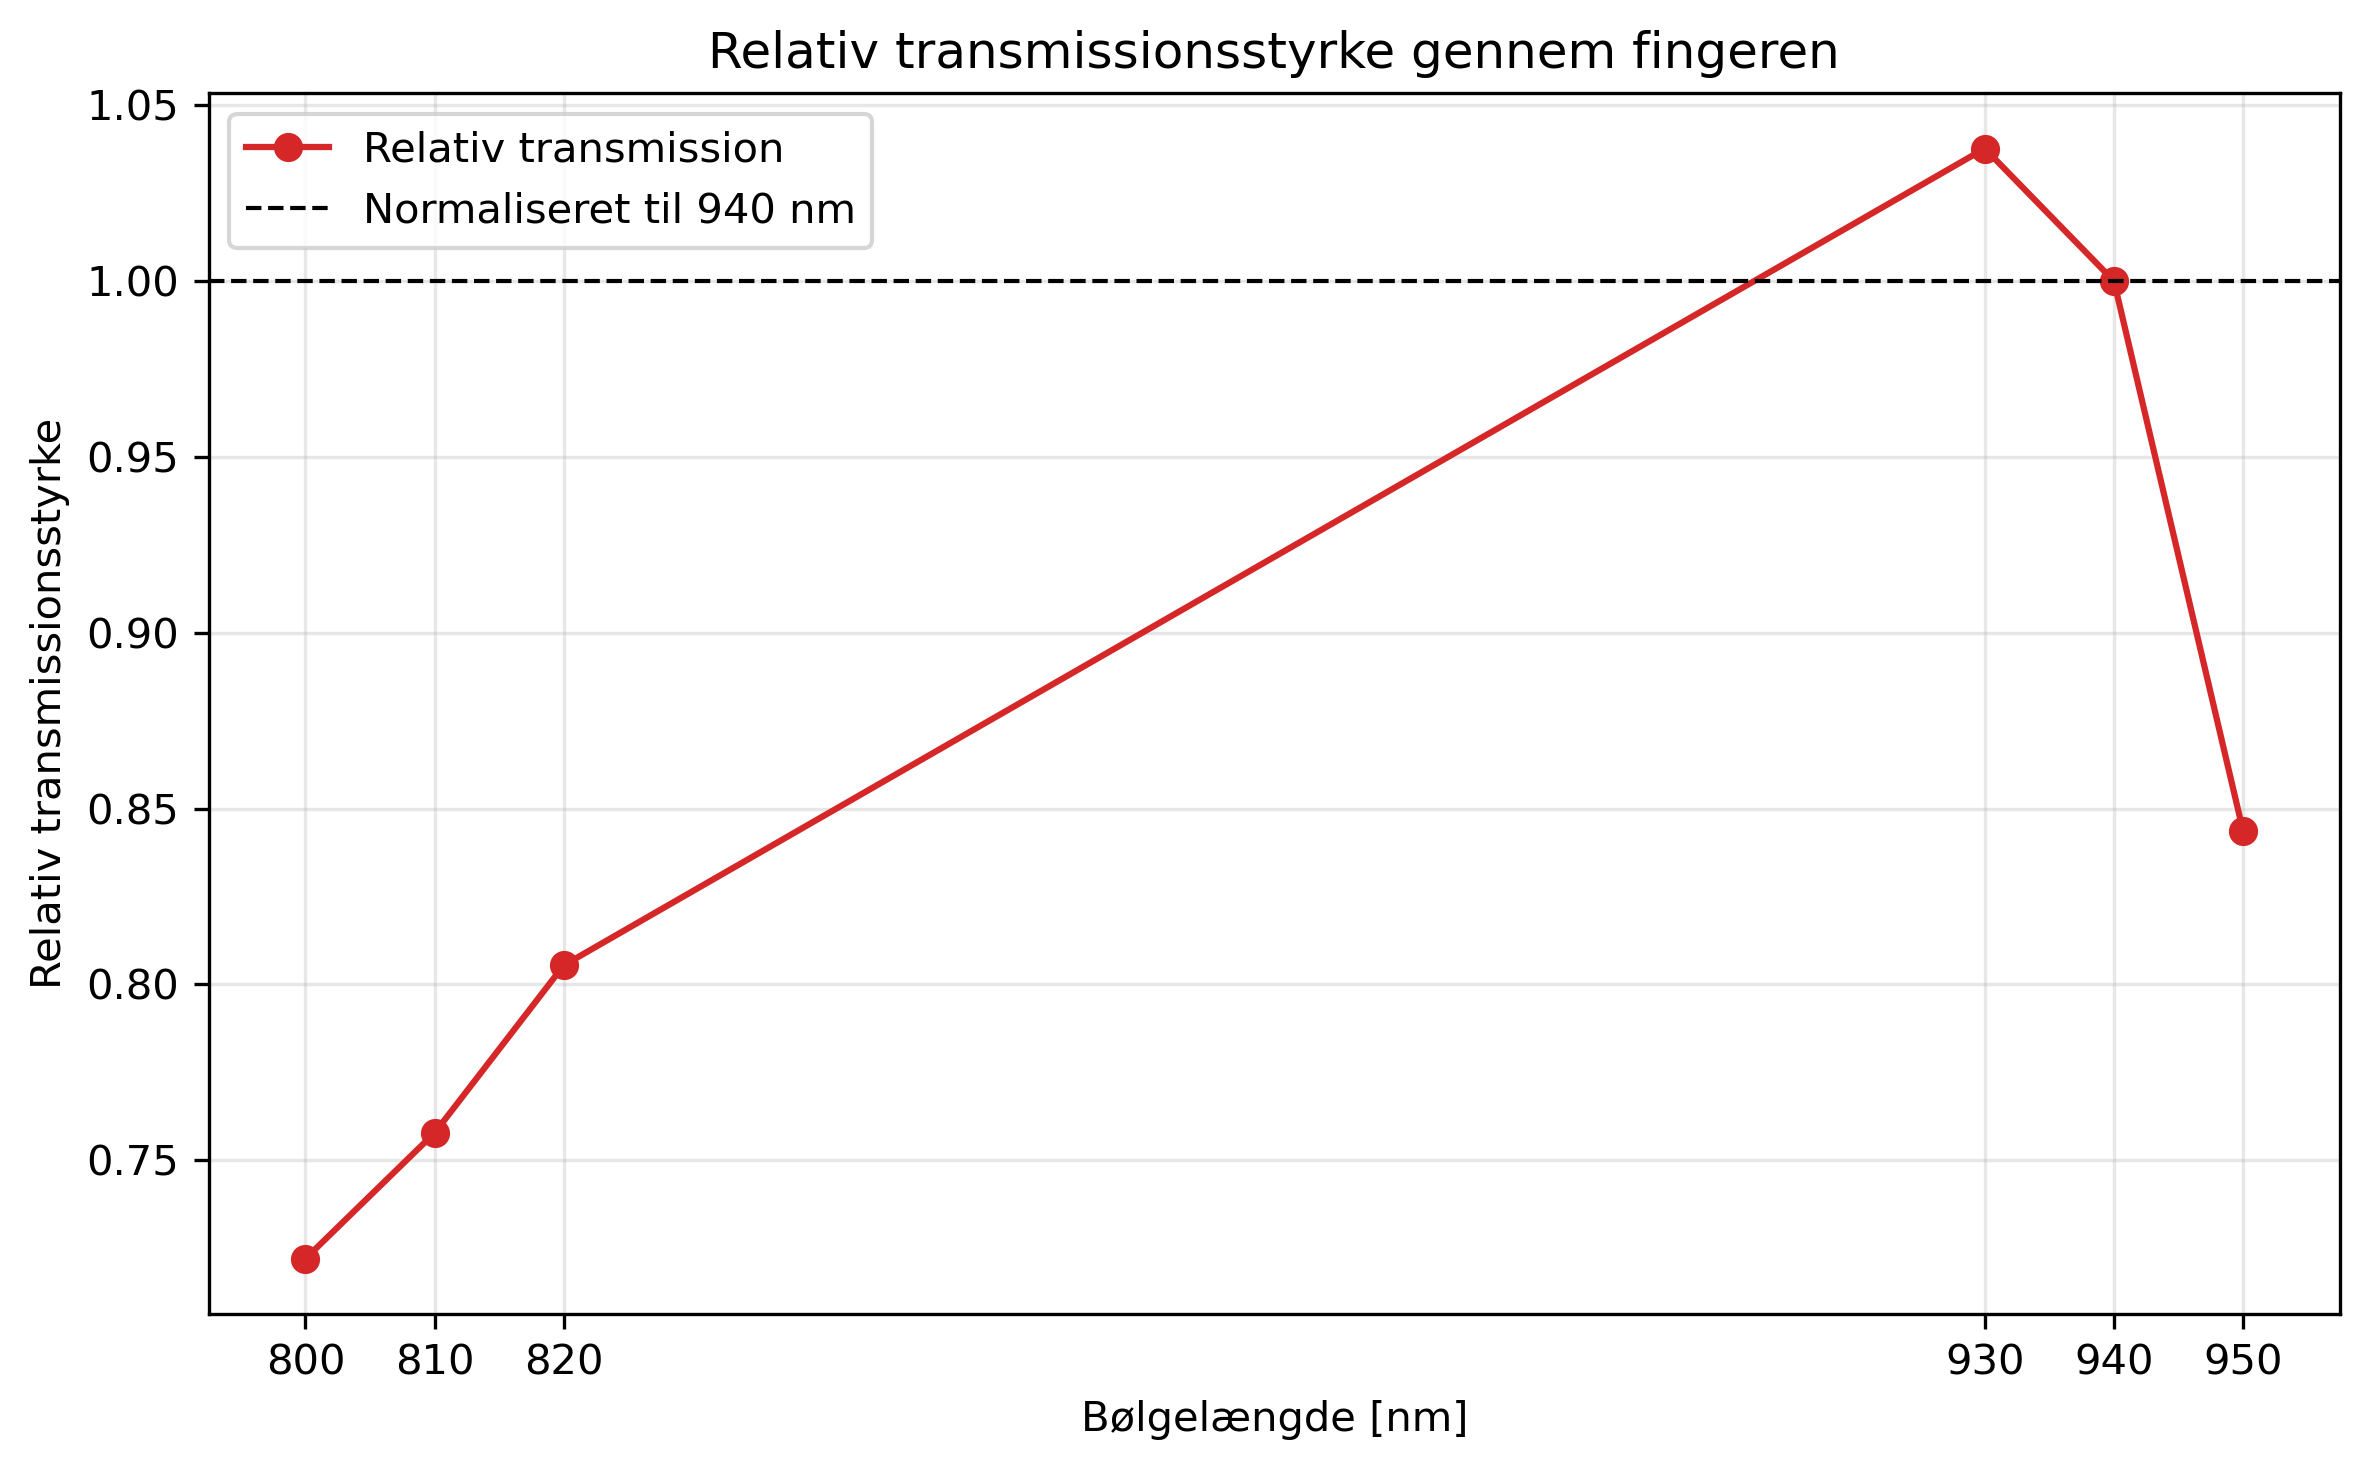

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=300)
plt.plot(
    df["wavelength_nm"],
    df["relative_finger_transmission_to_940"],
    marker="o",
    color="tab:red",
    label="Relativ transmission",
)

plt.axhline(1, color="black", linestyle="dashed", linewidth=1, label="Normaliseret til 940 nm")
plt.grid(alpha=0.3)
plt.xlabel("Bølgelængde [nm]")
plt.ylabel("Relativ transmissionsstyrke")
plt.title("Relativ transmissionsstyrke gennem fingeren")
plt.xticks(df["wavelength_nm"])
plt.legend()
plt.tight_layout()
# plt.savefig("/home/daniel/Desktop/Uni/6 Semester/Bachelorprojekt/bachelorprojekt/data/plots/relative_transmission_finger.pdf", bbox_inches="tight")
plt.show()
